In [1]:
import marker_utils
import scanpy as sc
import marker_utils.save_data as save_data

In [2]:
# Please ensure that the data's obs contains a celltype entry to indicate the cluster to which each cell belongs.
sc.read_h5ad('./example_data/rna.h5ad')

AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'clusters', 'celltype'

In [3]:
# Run with the default parameters.
info,adata=marker_utils.getMarkersEI('./example_data/rna.h5ad')

------Loading data------
------Data transposition------
2700 cells, 13714 genes.
------Step1: Calculate PCA------
------Step2: Calculate the similarity matrix------
------Step3: Adjust the expression value------
------Step4: Calculate EI------


cluster:Plateletrunningcalculate_EI(6/6): 100%|█| 9/9 [1:07:06<00:00, 447.36s/it

13.14 seconds used for calculate_mean_and_var.
3542.03 seconds used for calculate_smoothness.
2.62 seconds used for calculate_V.
4.47 seconds used for calculate_prop.
463.33 seconds used for calculate_local_mean_max.
0.20 seconds used for calculate_EI.
------Congratulations, success!------


In [4]:
# Print the first six Features.
six_features=info['B'].sort_values(by='EI', ascending=False).head(6)['Features'].tolist()
info['B'].sort_values(by='EI', ascending=False).head(6).reset_index(drop=True)

,Features,Mean,Smoothness,Local_max,V,Prop,Prop_sum,P,EI
0,CD79A,2.792081,0.000851,0.590439,9155.912285,3.692628e+40,3.204104e+09,0.166667,6.738190e-01
1,MS4A1,2.166752,0.002397,0.520608,1958.517294,2.147355e+37,2.293450e+06,0.111111,1.242472e-01
2,LINC00926,1.288178,0.010089,0.291720,164.477829,2.455711e+24,2.798141e+01,0.017131,1.145636e-10
3,TCL1A,1.748304,0.010923,0.484385,279.823146,7.567820e+26,5.674444e+04,0.083333,2.603133e-11
4,VPREB3,1.066071,0.013693,0.346800,83.001767,1.072274e+21,5.769147e+01,0.027778,1.185934e-14
5,BANK1,1.022469,0.012943,0.477146,80.771070,8.051303e+20,2.183431e+06,0.111111,2.089311e-19


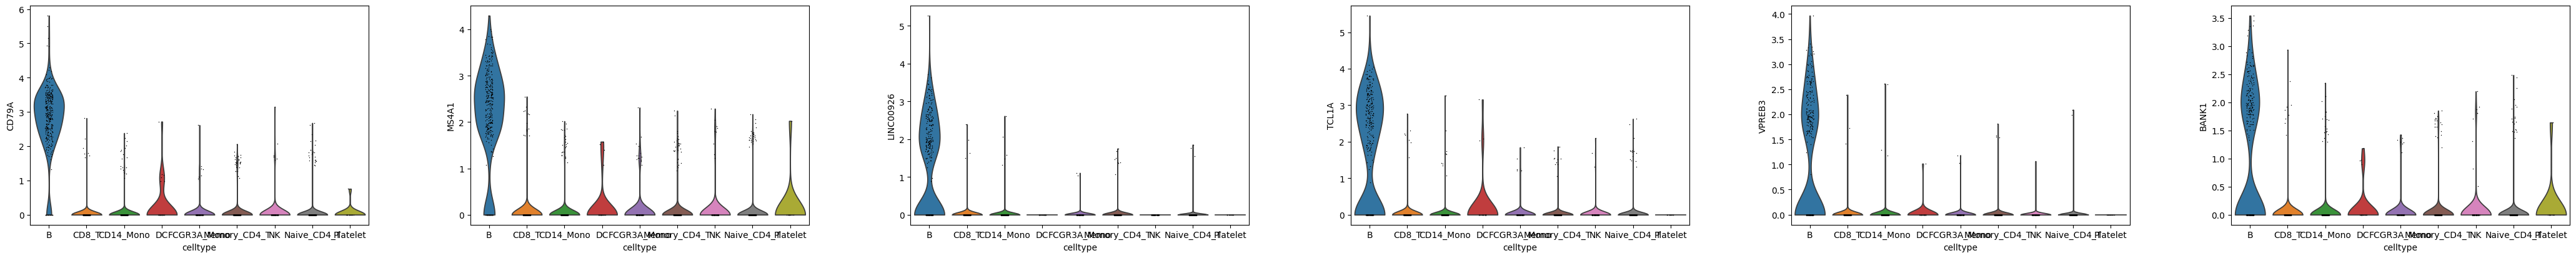

In [5]:
sc.pl.violin(adata,six_features,groupby="celltype")

In [6]:
# Obtain cluster-specific differentially expressed genes
sc.tl.rank_genes_groups(adata, groupby="celltype", method="wilcoxon")
sc.get.rank_genes_groups_df(adata, group="B").head(6)

,names,scores,logfoldchanges,pvals,pvals_adj
0,CD74,29.225498,4.091698,9.199467e-188,1.261615e-183
1,CD79A,28.018703,7.713846,9.615879e-173,6.593609e-169
2,HLA-DRA,27.897802,4.905622,2.836912e-171,1.296847e-167
3,CD79B,26.642738,5.502999,2.172398e-156,7.448065e-153
4,HLA-DPB1,26.108107,4.067628,2.949612e-150,8.090196e-147
5,MS4A1,25.503826,6.458750,1.787745e-143,4.086190e-140


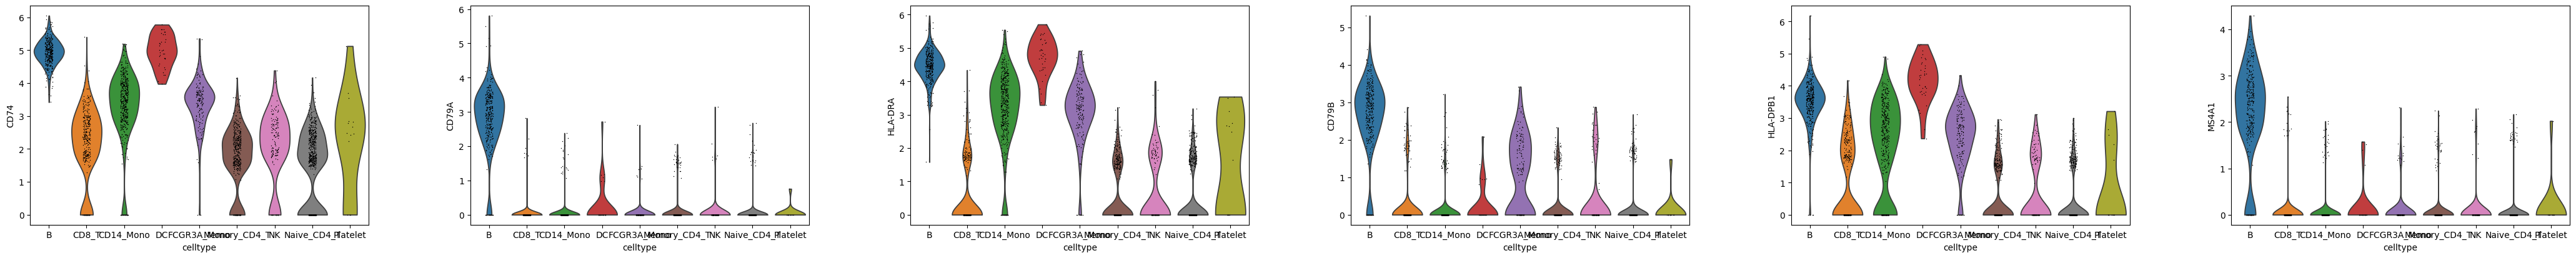

In [7]:
sc.pl.violin(adata,sc.get.rank_genes_groups_df(adata, group="B").head(6)['names'].tolist(),groupby="celltype")